In [17]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D
import pandas as pd
import ROOT
from scipy.optimize import curve_fit

In [18]:
file = ROOT.TFile.Open("../DetectorSimulation/output/default.root")
tracks = file.Get("tracks")
tracks.Print()

******************************************************************************
*Tree    :tracks    : Track parameters                                       *
*Entries :   500000 : Total =       105934121 bytes  File  Size =   67483079 *
*        :          : Tree compression factor =   1.57                       *
******************************************************************************
*Br    0 :MomentumX : Double_t tracks                                        *
*Entries :   500000 : Total  Size=    6014628 bytes  File Size  =    4481883 *
*Baskets :      130 : Basket Size=      32000 bytes  Compression=   1.34     *
*............................................................................*
*Br    1 :MomentumY : Double_t tracks                                        *
*Entries :   500000 : Total  Size=    6014628 bytes  File Size  =    4481963 *
*Baskets :      130 : Basket Size=      32000 bytes  Compression=   1.34     *
*...................................................

In [19]:
num_tracks = tracks.GetEntries()

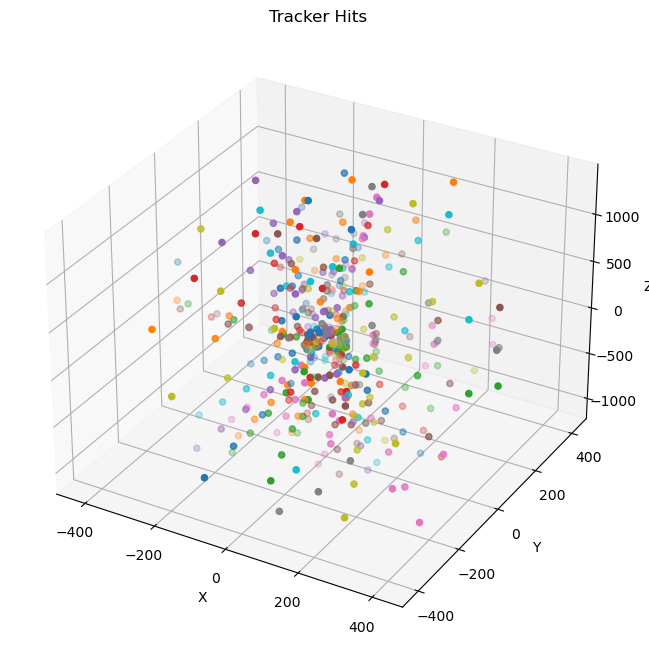

In [20]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('Tracker Hits')

for i in range(100):
    tracks.GetEntry(i)
    x = np.array(tracks.HitPositionX)
    y = np.array(tracks.HitPositionY)
    z = np.array(tracks.HitPositionZ)
    ax.scatter(x, y, z)

plt.show()

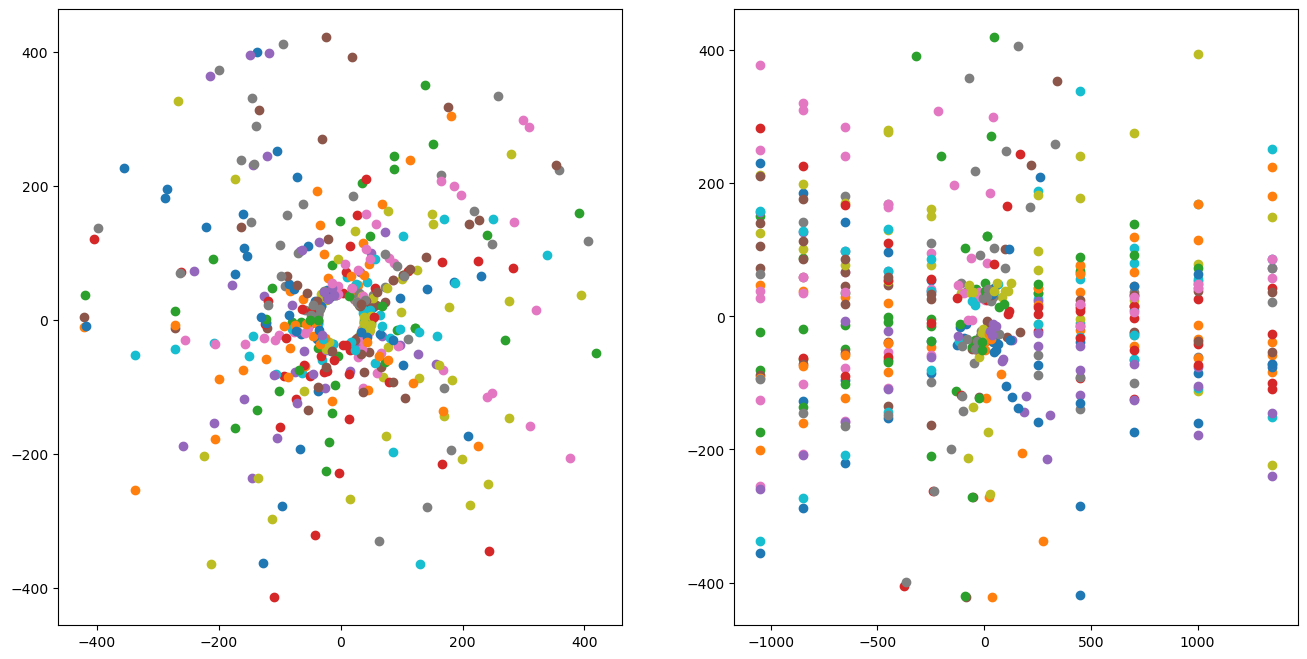

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

for i in range(100):
    tracks.GetEntry(i)
    x = np.array(tracks.HitPositionX)
    y = np.array(tracks.HitPositionY)
    z = np.array(tracks.HitPositionZ)
    axes[0].scatter(x, y)
    axes[1].scatter(z, x)

plt.show()

In [22]:
# for track in list(track_hits.values())[:100]:
#     x, y, z = zip(*track)
#     z = np.array(z)
#     z_scaled = (z - z[0]) / (z[-1] - z[0])
#     plt.plot(np.arange(len(z)), z)

# plt.show()

# First we cheat and skip the track finding step, and simply fit tracks

In [23]:
# num_hits_per_track = {}

# for eventID in track_hits:
#     num_hits_per_track[eventID] = len(track_hits[eventID])

# plt.hist(num_hits_per_track.values(), bins=max())
# plt.xlim(0, 20)

In [24]:
from helix_fitting import fit_helix, RMSE, helix

In [25]:
def gaussian(x, A, x_0, sigma):
    return A * np.exp(-(x - x_0)**2 / (2 * sigma**2))

In [27]:
B = 1.7

cutoff_momentum = 50_000 # 50 MeV

data = []

for i in range(num_tracks):
    tracks.GetEntry(i)
    if tracks.NumHits < 4:
        continue
    x = np.array(tracks.HitPositionX)
    y = np.array(tracks.HitPositionY)
    z = np.array(tracks.HitPositionZ)
    d0, z0, phi0, pT, tanl = fit_helix(x, y, z, B)

    fitted_pZ = tanl * pT
    fitted_p = np.sqrt(pT ** 2 + fitted_pZ ** 2)

    pX, pY, pZ = tracks.MomentumX, tracks.MomentumY, tracks.MomentumZ
    p = np.sqrt(pX ** 2 + pY ** 2 + pZ ** 2)
    eta = np.arctanh(pZ / p)

    if fitted_p > cutoff_momentum:
        continue

    data.append({
        "True p": round(p),
        "True pX": pX,
        "True pY": pY,
        "True pZ": pZ,
        "eta": eta,
        "Fit d0": d0,
        "Fit z0": z0,
        "Fit phi0": phi0,
        "Fit pT": pT,
        "Fit tanl": tanl,
        "NumHits": tracks.NumHits
    })

df2 = pd.DataFrame(data)
df2.head()

,True p,True pX,True pY,True pZ,eta,Fit d0,Fit z0,Fit phi0,Fit pT,Fit tanl,NumHits
0,3000,624.793844,239.887688,-2924.395074,-2.180656,0.040919,0.443043,-2.773951,672.104575,-4.379677,5
1,2000,-105.891913,266.782557,1979.296332,2.629275,-0.469857,1.198012,-1.207042,295.532258,6.871013,4
2,2000,72.762942,208.478609,1987.773182,2.893678,0.466851,0.348136,-1.896210,216.697412,9.001128,4
3,700,-679.026891,-102.071592,-136.028937,-0.196830,-0.009862,0.028712,0.148733,688.576933,-0.198311,5
4,1000,626.216699,773.990247,93.764303,0.094041,0.007838,-0.019249,-2.250783,992.970065,0.094462,5


In [81]:
def gaussian_sigma(data):
    sigma_guess = (np.percentile(data, 84) - np.percentile(data, 16)) / 2

    mean = data.mean() 
    counts, edges = np.histogram(data, bins=50, range=(mean - 2 * sigma_guess, mean + 2 * sigma_guess))
    mids = (edges[:-1] + edges[1:]) / 2

    try:
        popt, _ = curve_fit(gaussian, mids, counts, p0=[max(counts), mids[np.argmax(counts)], sigma_guess])
        return abs(popt[2]) 
    except:
        print("Fitting failed")
        return sigma_guess

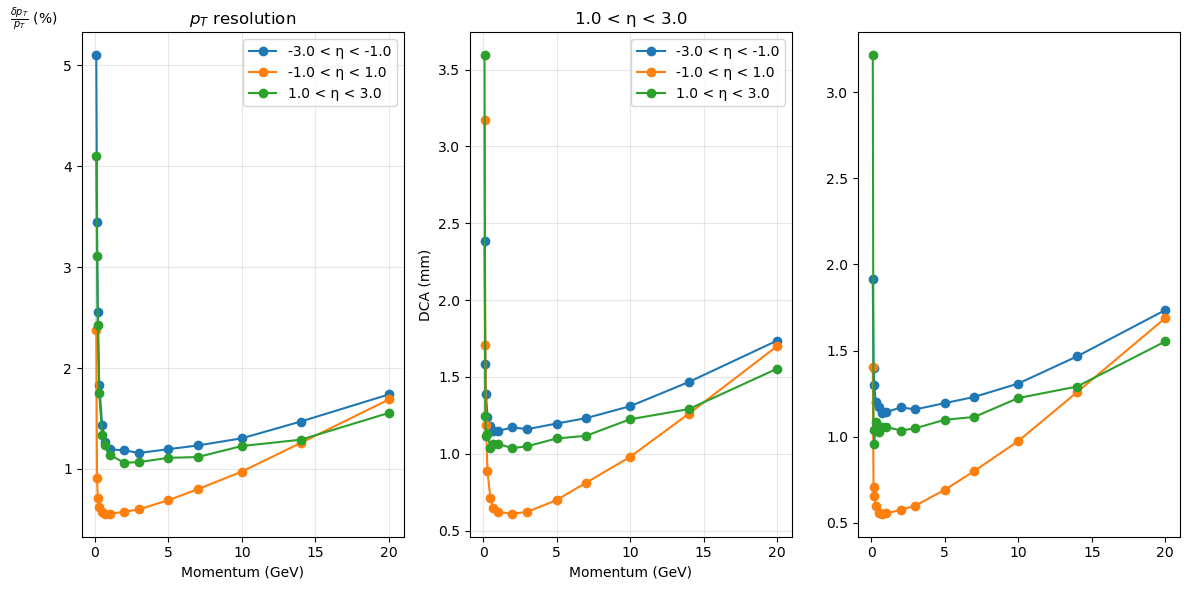

In [82]:
fig, axes = plt.subplots(1, 3, figsize=(12, 6))

eta_bins = [
    (-3.0, -1.0),
    (-1.0,  1.0),
    ( 1.0, 3.0),
]

for i, (eta_lo, eta_hi) in enumerate(eta_bins):
    df_eta = df2[(df2["eta"] >= eta_lo) &
                (df2["eta"] < eta_hi)]
    
    momentum_points = sorted(df_eta["True p"].unique())

    p_GeV = []
    sigma_delta_pT = []
    sigma_delta_p = []
    sigma_delta_pZ = []
    sigma_delta_d0 = []
    sigma_delta_z0 = []

    for p in momentum_points[:]:
        subset = df_eta[df_eta["True p"] == p]
        p_GeV.append(p / 1000)

        true_pT = np.sqrt(subset["True pX"] ** 2 + subset["True pY"] ** 2)
        fit_p = subset["Fit pT"] * np.sqrt(1 + subset["Fit tanl"] ** 2)
        true_phi0 = np.arctan2(subset["True pY"], subset["True pX"])
        pT_residual = (subset["Fit pT"] - true_pT) / true_pT
        pZ_residual = (subset["Fit pT"] * subset["Fit tanl"] - subset["True pZ"]) / subset["True pZ"]
        p_residual = (fit_p - subset["True p"]) / subset["True p"]

        sigma_delta_pT.append(gaussian_sigma(pT_residual))
        sigma_delta_pZ.append(gaussian_sigma(pZ_residual))
        sigma_delta_p.append(gaussian_sigma(p_residual))


    axes[0].plot(p_GeV, np.array(sigma_delta_pT) * 100, marker="o", label=f"{eta_lo} < η < {eta_hi}")
    axes[1].plot(p_GeV, np.array(sigma_delta_pZ) * 100, marker="o", label=f"{eta_lo} < η < {eta_hi}")
    axes[2].plot(p_GeV, np.array(sigma_delta_p) * 100, marker="o", label=f"{eta_lo} < η < {eta_hi}")

    axes[0].set_title("$p_T$ resolution")
    axes[0].set_xlabel("Momentum (GeV)")
    axes[0].set_ylabel("$\\frac{\delta p_T}{p_T}$ (%)", rotation="horizontal", loc="top")
    axes[0].grid(alpha=0.3)
    axes[0].legend()

    axes[1].set_title(f"{eta_lo} < η < {eta_hi}")
    axes[1].set_xlabel("Momentum (GeV)")
    axes[1].set_ylabel("DCA (mm)")
    axes[1].grid(alpha=0.3)
    axes[1].legend()

plt.tight_layout()
plt.show()

150 0
200 0
300 0
500 0
700 0
1000 0
2000 0
3000 0
5000 0
7000 0
10000 0
14000 0
20000 0
150 1
200 1
Fitting failed
300 1
500 1
700 1
1000 1
2000 1
3000 1
5000 1
7000 1
10000 1
14000 1
20000 1
150 2
200 2
300 2
500 2
700 2
1000 2
2000 2
3000 2
5000 2
7000 2
10000 2
14000 2
20000 2


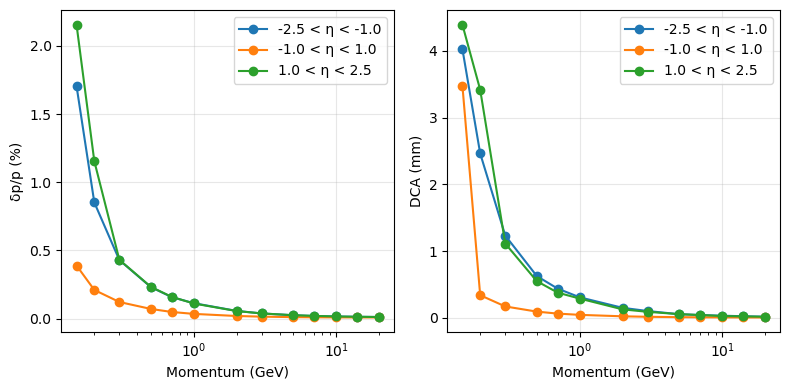

In [94]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

eta_bins = [
    (-2.5, -1.0),
    (-1.0,  1.0),
    ( 1.0, 2.5),
]

for i, (eta_lo, eta_hi) in enumerate(eta_bins):
    df_eta = df2[(df2["eta"] >= eta_lo) &
                (df2["eta"] < eta_hi)]
    
    momentum_points = sorted(df_eta["True p"].unique())

    p_GeV = []
    sigma_delta_d0 = []
    sigma_delta_z0 = []

    for p in momentum_points[1:]:
        subset = df_eta[df_eta["True p"] == p]
        p_GeV.append(p / 1000)

        print(p, i)

        sigma_delta_d0.append(gaussian_sigma(subset["Fit d0"]))
        sigma_delta_z0.append(gaussian_sigma(subset["Fit z0"]))


    axes[0].plot(p_GeV, sigma_delta_d0, marker="o", label=f"{eta_lo} < η < {eta_hi}")
    axes[1].plot(p_GeV, sigma_delta_z0, marker="o", label=f"{eta_lo} < η < {eta_hi}")

    axes[0].set_xlabel("Momentum (GeV)")
    axes[0].set_ylabel("δp/p (%)")
    axes[0].set_xscale("log")
    axes[0].grid(alpha=0.3)
    axes[0].legend()

    axes[1].set_xlabel("Momentum (GeV)")
    axes[1].set_ylabel("DCA (mm)")
    axes[1].set_xscale("log")
    axes[1].grid(alpha=0.3)
    axes[1].legend()

plt.tight_layout()
plt.show()

5.042096312064887 0.33931826567517487


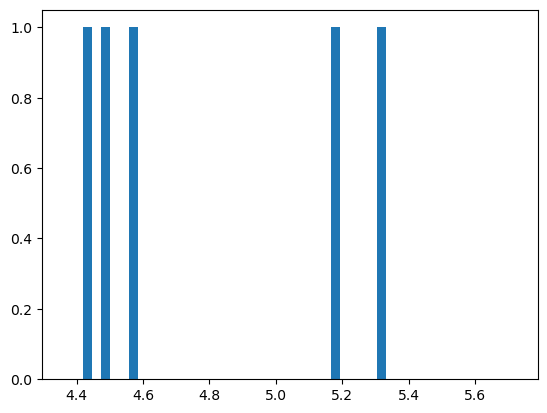

In [89]:
df_eta = df2[(df2["eta"] >= -1) &
            (df2["eta"] < 1)]

subset = df_eta[df_eta["True p"] == 200]
data = subset["Fit z0"]

sigma_guess = (np.percentile(data, 84) - np.percentile(data, 16)) / 2

mean = data.mean() 
# counts, edges = np.histogram(data, bins=50, range=(mean - 2 * sigma_guess, mean + 2 * sigma_guess))
# mids = (edges[:-1] + edges[1:]) / 2

# plt.plot(mids, counts)

plt.hist(data, bins=np.linspace(mean - 2 * sigma_guess, mean + 2 * sigma_guess, 50))
print(mean, sigma_guess)

(0.0, 1000.0)

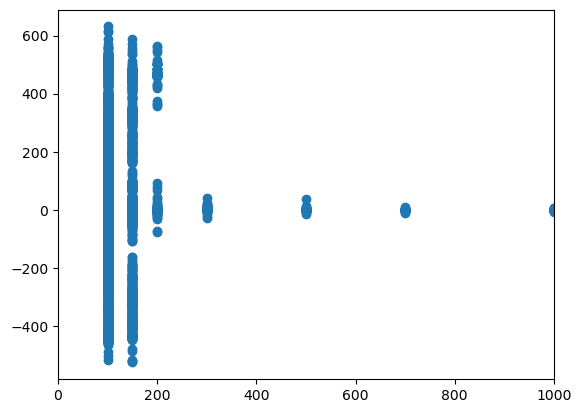

In [93]:
df_eta = df2[(df2["eta"] >= -1) &
            (df2["eta"] < 1)]

plt.scatter(df_eta["True p"], df_eta["Fit z0"])
plt.xlim(0, 1000)

In [74]:
phi_diff = (subset["Fit phi0"] - np.arctan2(subset["True pY"], subset["True pX"]))

np.arctan2(np.cos(phi_diff), np.sin(phi_diff))

14       -1.570894
102      -1.571183
120      -1.570389
259      -1.570314
270      -1.570665
            ...   
419941   -1.570159
419974   -1.571179
420131   -1.570350
420215   -1.570972
420232   -1.570450
Length: 9986, dtype: float64

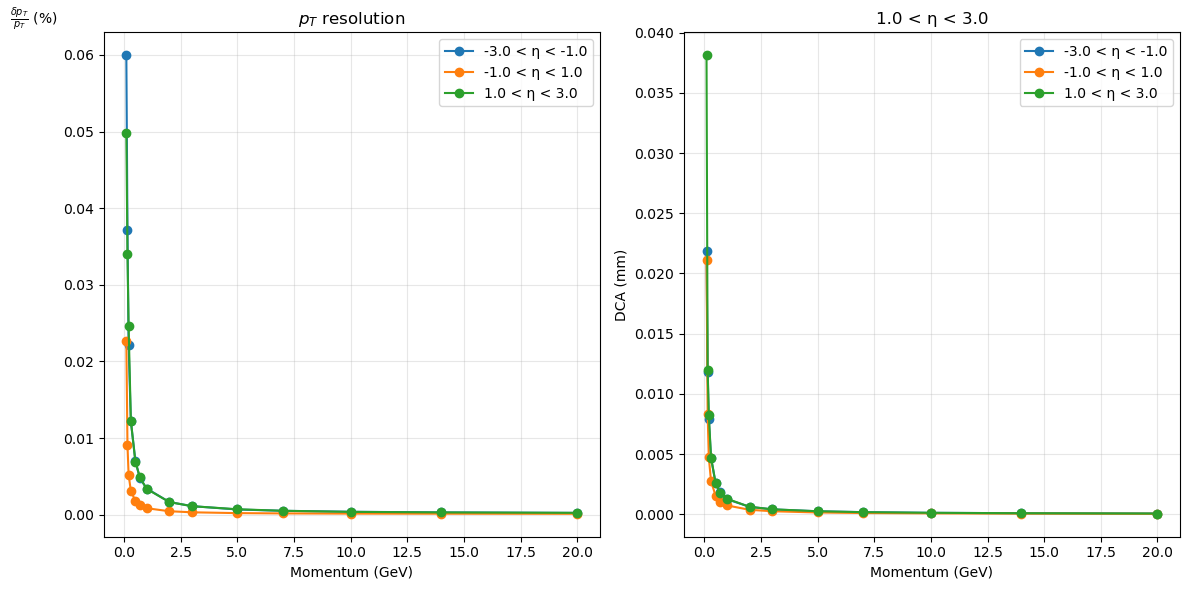

In [75]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

eta_bins = [
    (-3.0, -1.0),
    (-1.0,  1.0),
    ( 1.0, 3.0),
]

for i, (eta_lo, eta_hi) in enumerate(eta_bins):
    df_eta = df2[(df2["eta"] >= eta_lo) &
                (df2["eta"] < eta_hi)]
    
    momentum_points = sorted(df_eta["True p"].unique())

    p_GeV = []
    sigma_delta_phi0 = []
    sigma_delta_theta = []

    for p in momentum_points[:]:
        subset = df_eta[df_eta["True p"] == p]
        if (len(subset.index) < 10):
            continue
        p_GeV.append(p / 1000)

        true_pT = np.sqrt(subset["True pX"] ** 2 + subset["True pY"] ** 2)

        phi_diff = (subset["Fit phi0"] - np.arctan2(subset["True pY"], subset["True pX"]))

        phi0_residual = np.arctan2(np.cos(phi_diff), np.sin(phi_diff))
        theta_residual = (np.arctan(subset["Fit tanl"]) - np.arctan(subset["True pZ"] / true_pT))

        sigma_delta_phi0.append(gaussian_sigma(phi0_residual))
        sigma_delta_theta.append(gaussian_sigma(theta_residual))


    axes[0].plot(p_GeV, np.array(sigma_delta_phi0), marker="o", label=f"{eta_lo} < η < {eta_hi}")
    axes[1].plot(p_GeV, np.array(sigma_delta_theta), marker="o", label=f"{eta_lo} < η < {eta_hi}")

    axes[0].set_title("$p_T$ resolution")
    axes[0].set_xlabel("Momentum (GeV)")
    axes[0].set_ylabel("$\\frac{\delta p_T}{p_T}$ (%)", rotation="horizontal", loc="top")
    axes[0].grid(alpha=0.3)
    axes[0].legend()

    axes[1].set_title(f"{eta_lo} < η < {eta_hi}")
    axes[1].set_xlabel("Momentum (GeV)")
    axes[1].set_ylabel("DCA (mm)")
    axes[1].grid(alpha=0.3)
    axes[1].legend()

plt.tight_layout()
plt.show()

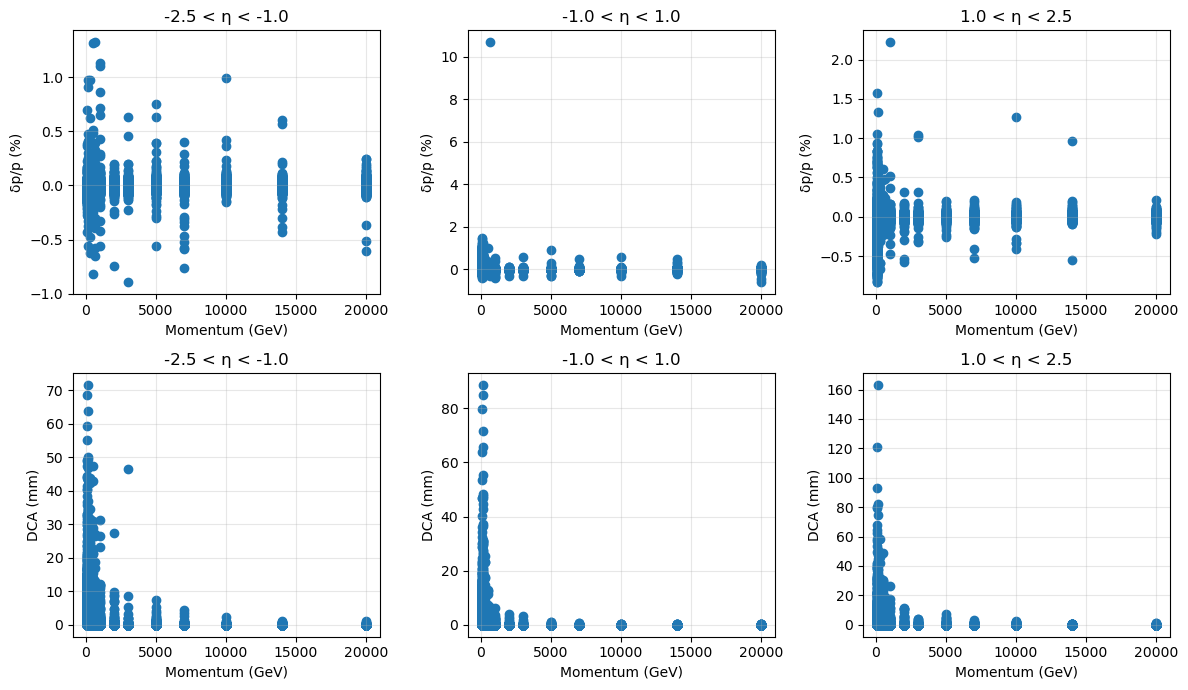

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(12, 7))

eta_bins = [
    (-2.5, -1.0),
    (-1.0,  1.0),
    ( 1.0,  2.5),
]

for i, (eta_lo, eta_hi) in enumerate(eta_bins):
    df_eta = df[(df["Pseudorapidity"] >= eta_lo) &
                (df["Pseudorapidity"] < eta_hi)]
    
    momentum_points = sorted(df_eta["True Momentum (MeV/c)"].unique())

    p_residual = (df_eta["Fitted Momentum (MeV/c)"] - df_eta["True Momentum (MeV/c)"]) / df_eta["True Momentum (MeV/c)"]

    axes[0, i].scatter(df_eta["True Momentum (MeV/c)"], p_residual)
    axes[1, i].scatter(df_eta["True Momentum (MeV/c)"], df_eta["DCA (mm)"])

    axes[0, i].set_title(f"{eta_lo} < η < {eta_hi}")
    axes[0, i].set_xlabel("Momentum (GeV)")
    axes[0, i].set_ylabel("δp/p (%)")
    axes[0, i].grid(alpha=0.3)

    axes[1, i].set_title(f"{eta_lo} < η < {eta_hi}")
    axes[1, i].set_xlabel("Momentum (GeV)")
    axes[1, i].set_ylabel("DCA (mm)")
    axes[1, i].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
plt.scatter(df["Momentum (MeV/c)"], df["DCA (mm)"], alpha=0.01)
plt.xlabel("True Momentum (MeV/c)")
plt.ylabel("DCA (mm)")
plt.title("DCA vs True Momentum")
plt.show()

KeyError: 'Momentum (MeV/c)'

In [ ]:
plt.scatter(df["Momentum (MeV/c)"], df["z0 (mm)"], alpha=0.01)
plt.xlabel("True Momentum (MeV/c)")
plt.ylabel("z0 (mm)")
plt.title("z0 vs True Momentum")
plt.show()

In [ ]:
plt.scatter(df["Pseudorapidity"], df["Momentum Accuracy (%)"])
plt.xlabel("η")
plt.ylabel("Δp/p (%)")
plt.title("Momentum Accuracy vs Pseudorapidity")
plt.show()

In [ ]:
plt.scatter(df["Transverse Momentum Accuracy (%)"], df["Z Momentum Accuracy (%)"], alpha=0.01)
plt.ylim(0, 200)
plt.plot()

In [ ]:
plt.hist(df["Z Momentum Accuracy (%)"], bins=np.arange(0, 300, 0.5))
plt.xlim(-50, 250)
plt.show()

In [ ]:
plt.scatter(df["Momentum (MeV/c)"], df["Momentum Accuracy (%)"], alpha=0.01)
plt.xlabel("Momentum (MeV/c)")
plt.ylabel("Δp/p (%)")
plt.title("Momentum Accuracy vs Momentum")
plt.ylim(0, 200)
plt.xlim(0, 2500)
plt.show()

In [ ]:
plt.scatter(df["RMSE"], df["Momentum Accuracy (%)"], alpha=0.05)
plt.xlabel("RMSE")
plt.ylabel("Δp/p (%)")
plt.title("Momentum Accuracy vs RMSE")
plt.ylim(0, 500)
plt.xlim(-50, 500)
plt.show()

In [ ]:
plt.scatter(df["RMSE"], df["DCA (mm)"], alpha=0.1)
plt.xlabel("RMSE")
plt.ylabel("DCA (mm)")
plt.title("DCA Accuracy vs RMSE")
plt.ylim(0, 20)
plt.xlim(-10, 200)
plt.show()

In [ ]:
plt.scatter( df["Momentum (MeV/c)"], df["RMSE"], alpha=0.1)
plt.xlabel("Momentum (MeV/c)")
plt.ylabel("RMSE")
plt.title("Momentum vs RMSE")
plt.xlim(1000, 20000)
plt.ylim(-1, 3)
plt.show()

In [ ]:
df.sort_values(by="Momentum Accuracy (%)", ascending=False).head(100)

In [ ]:
df.sort_values(by="RMSE", ascending=False).head()

In [ ]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

track = track_hits[632]
x, y, z = track

ax.scatter(x, y, z, c="r")

x_c, y_c, R, tanl, z0, phi = fit_helix(x, y, z)

fitted_pT, fitted_pZ = momentum_from_helix(R, tanl, B)
fitted_DCA = DCA_from_helix(x_c, y_c, R)

phi0 = phi[0]
sample_phi = np.linspace(phi[0], phi[-1], 1000)
x_fit, y_fit, z_fit = helix(x_c, y_c, z0, fitted_pZ, fitted_pT, R, sample_phi)
ax.plot(x_fit, y_fit, z_fit)

In [ ]:
plt.scatter(x, y)
plt.plot(x_fit, y_fit)

In [ ]:
plt.scatter(phi, z)
plt.plot(sample_phi, z_fit)

In [ ]:
plt.scatter(x, z)
plt.plot(x_fit, z_fit)